H3K27ac ChIP-seq — TSS-centred (AlphaGenome) 

Note that H3K27ac is specific for active enhancers and promoters

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from alphagenome.models import dna_client

pd.set_option('display.max_columns', None)
DATA = next(d for d in ('data', '../data', 'v2/data', '../v2/data', '../../data') if os.path.isdir(d))
tss_centered = pd.read_csv(f'{DATA}/TSS_centered_data.csv')

def _api_key():
    k = os.environ.get('ALPHA_GENOME_API_KEY')
    if k:
        return k
    for p in ('.env', '../.env', '../../.env', '../../../.env'):
        if os.path.exists(p):
            for line in open(p):
                if line.startswith('ALPHA_GENOME_API_KEY='):
                    return line.split('=', 1)[1].strip().strip('"\'')
    raise RuntimeError('ALPHA_GENOME_API_KEY not found')

model = dna_client.create(_api_key())
CHIP = dna_client.OutputType.CHIP_HISTONE
W, BIN_BP = 1_048_576, 128                  # ChIP-histone output = 8192 bins x 128 bp

def predict_h3k27ac(seq, ontology):
    """Predicted H3K27ac coverage (128 bp bins) for the cell type; unstranded."""
    td = model.predict_sequence(seq, requested_outputs=[CHIP], ontology_terms=[ontology]).chip_histone
    vals, meta = np.asarray(td.values), td.metadata
    cols = np.where(meta['histone_mark'].values == 'H3K27ac')[0]
    assert len(cols), f'no H3K27ac track for {ontology}'
    return vals[:, cols].mean(axis=1)

/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json, urllib.request

TRANSCRIPTS = {'EVI1 (MECOM)': 'ENST00000264674', 'TAL1': 'ENST00000691006',
               'ETV1': 'ENST00000430479', 'MNX1': 'ENST00000252971'}

def fetch_exons(tx):
    url = f'https://rest.ensembl.org/lookup/id/{tx}?expand=1;content-type=application/json'
    return [(e['start'], e['end']) for e in json.load(urllib.request.urlopen(url, timeout=60))['Exon']]

exons = {g: fetch_exons(tx) for g, tx in TRANSCRIPTS.items()}

In [3]:
def coords(track, tss, strand):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(len(track)) - len(track) // 2) * BIN_BP / 1000     # kb from TSS, 128 bp bins
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    return x, span

def plot_overlay(gene, wt, der, tss, strand, exon_list, title, desc, enh=None, half=150, ymax_fixed=None):
    x, span = coords(wt, tss, strand)
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    vis = np.abs(x) <= half
    ymax = ymax_fixed if ymax_fixed is not None else max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4)
    eh = ymax * 0.05
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.plot(x, wt,  lw=0.9, color='0.55', ls='--', zorder=3)                  # WT  = gray dashed
    ax.plot(x, der, lw=1.0, color='steelblue', zorder=4)                      # der = blue
    ax.axhline(0, color='0.7', lw=0.5); ax.axvline(0, color='0.7', ls=':', lw=0.7)
    for s, e in exon_list:
        a, b = span(s, e)
        ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh, color='firebrick', lw=0, zorder=5, clip_on=True))
    if enh is not None:
        ex0, ex1 = span(*enh)
        if ex1 >= -half and ex0 <= half:
            ax.add_patch(plt.Rectangle((max(ex0, -half), -1.5 * eh), min(ex1, half) - max(ex0, -half), eh, color='darkorange', lw=0, zorder=6, clip_on=True))
    ax.plot([max(ga, -half), min(gb, half)], [-2.7 * eh, -2.7 * eh], lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
    ax.text(np.clip((ga + gb) / 2, -half, half), -2.7 * eh, gene.split()[0], ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7, bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
    ax.set_xlim(-half, half); ax.set_ylim(-3.7 * eh, ymax)
    ax.set_ylabel('pred H3K27ac'); ax.set_xlabel('kb from TSS (gene body = positive)')
    ax.legend(handles=[Line2D([0], [0], color='steelblue', lw=1.5, label='der'),
                       Line2D([0], [0], color='0.55', lw=1.5, ls='--', label='WT'),
                       Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon'),
                       Patch(facecolor='darkorange', label='enhancer')],
              loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    ax.set_title(f"{title}\n{desc}", fontsize=10, loc='left'); fig.tight_layout()

In [4]:
# one der per oncogene (MNX1 -> @10 kb row); predict H3K27ac for WT and der
panel = tss_centered.dropna(subset=['onco_tss', 'element_len']).drop_duplicates('driven_gene').reset_index(drop=True)
panel['onco_tss'] = panel['onco_tss'].astype(int)

def _enh(wt_seq, der_seq, tss):
    d = np.where(np.frombuffer(wt_seq.encode(), 'S1') != np.frombuffer(der_seq.encode(), 'S1'))[0]
    return (tss - W // 2 + int(d[0]), tss - W // 2 + int(d[-1]) + 1) if len(d) else None

chip = {}
for r in panel.itertuples():
    chip[r.driven_gene] = dict(wt=predict_h3k27ac(r.wt_seq, r.ontology),
                               der=predict_h3k27ac(r.der_seq, r.ontology),
                               enh=_enh(r.wt_seq, r.der_seq, int(r.onco_tss)),
                               tss=int(r.onco_tss), strand=r.strand, cell=r.cell_context,
                               insert_kb=r.insert_kb_from_TSS)
list(chip)

['EVI1 (MECOM)', 'TAL1', 'ETV1', 'MNX1']

## H3K27ac: WT vs der (wide)

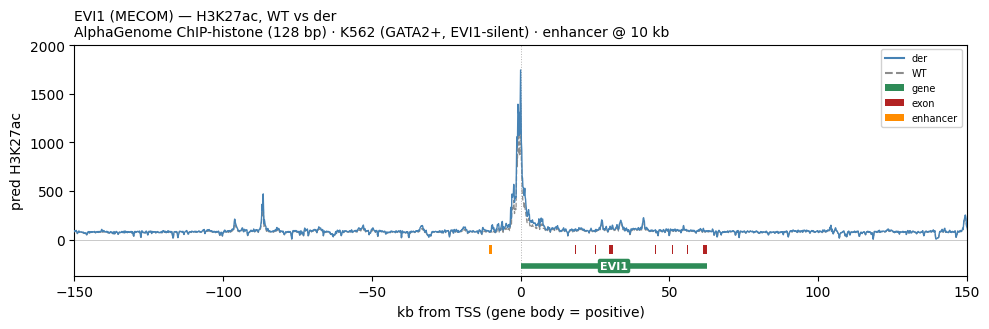

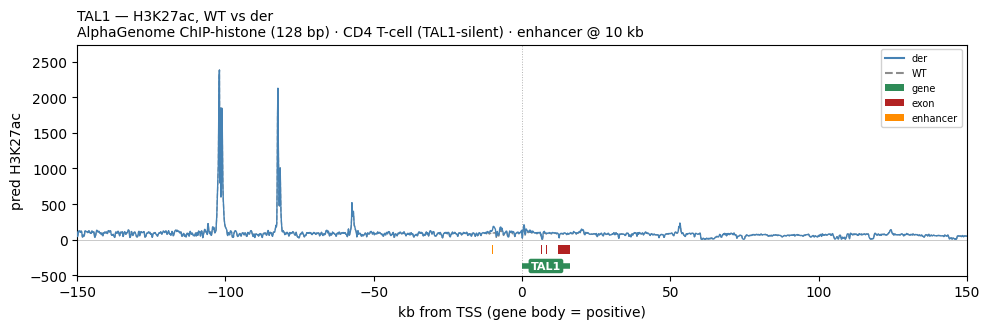

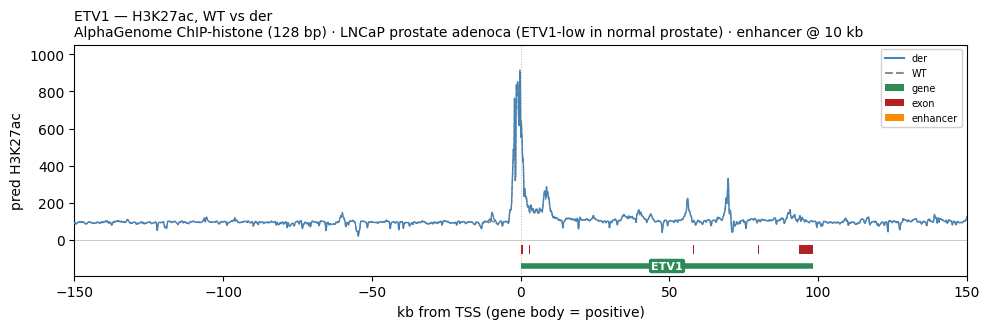

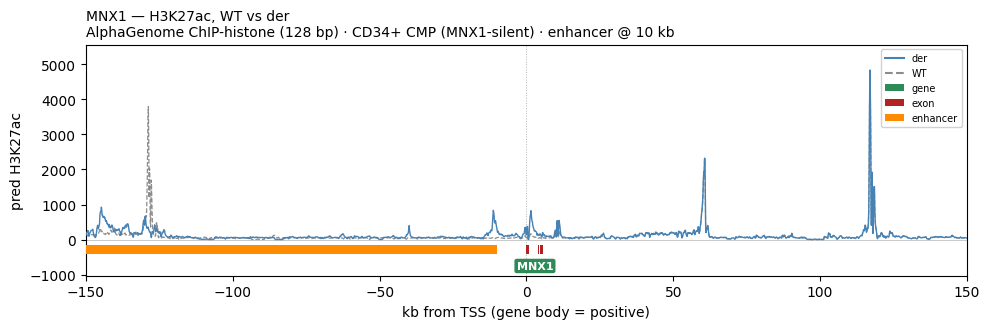

In [5]:
for g in chip:
    c = chip[g]
    plot_overlay(g, c['wt'], c['der'], c['tss'], c['strand'], exons[g],
                 f"{g} \u2014 H3K27ac, WT vs der",
                 f"AlphaGenome ChIP-histone (128 bp) \u00b7 {c['cell']} \u00b7 enhancer @ {c['insert_kb']:.0f} kb",
                 enh=c['enh'], half=150)

## H3K27ac at the promoter (close up)

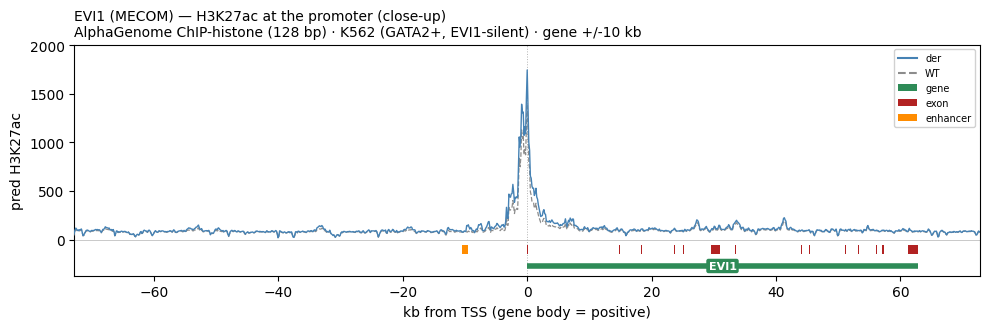

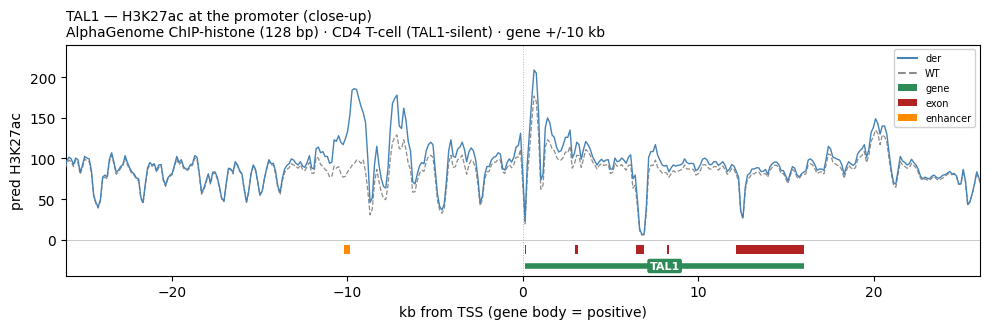

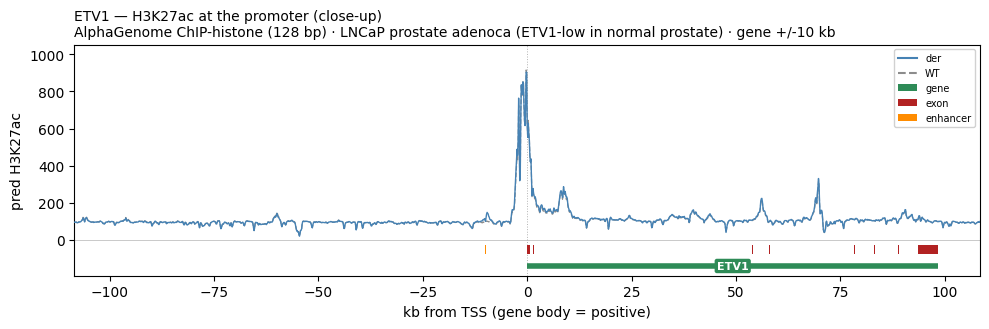

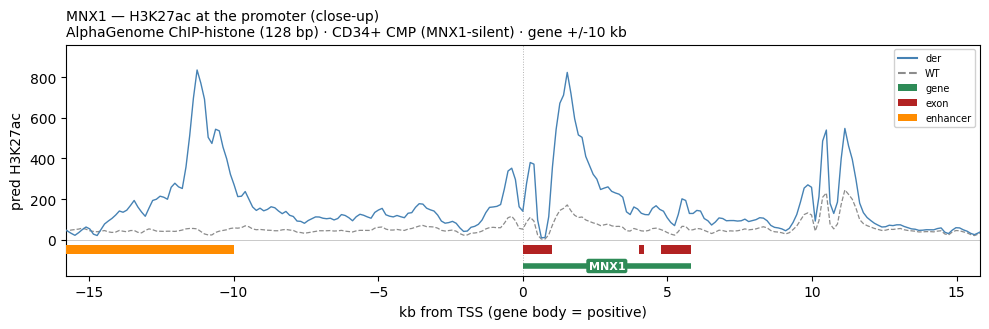

: 

In [ ]:
for g in chip:
    c = chip[g]; ex = exons[g]
    _, span = coords(c['wt'], c['tss'], c['strand']); ga, gb = span(min(s for s, e in ex), max(e for s, e in ex))
    plot_overlay(g, c['wt'], c['der'], c['tss'], c['strand'], ex,
                 f"{g} \u2014 H3K27ac at the promoter (close-up)",
                 f"AlphaGenome ChIP-histone (128 bp) \u00b7 {c['cell']} \u00b7 gene +/-10 kb",
                 enh=c['enh'], half=max(abs(ga), abs(gb)) + 10)